# Training a LeNet on CIFAR10
ref: https://github.com/rasbt/deeplearning-models/blob/master/pytorch_ipynb/cnn/cnn-lenet5-cifar10.ipynb





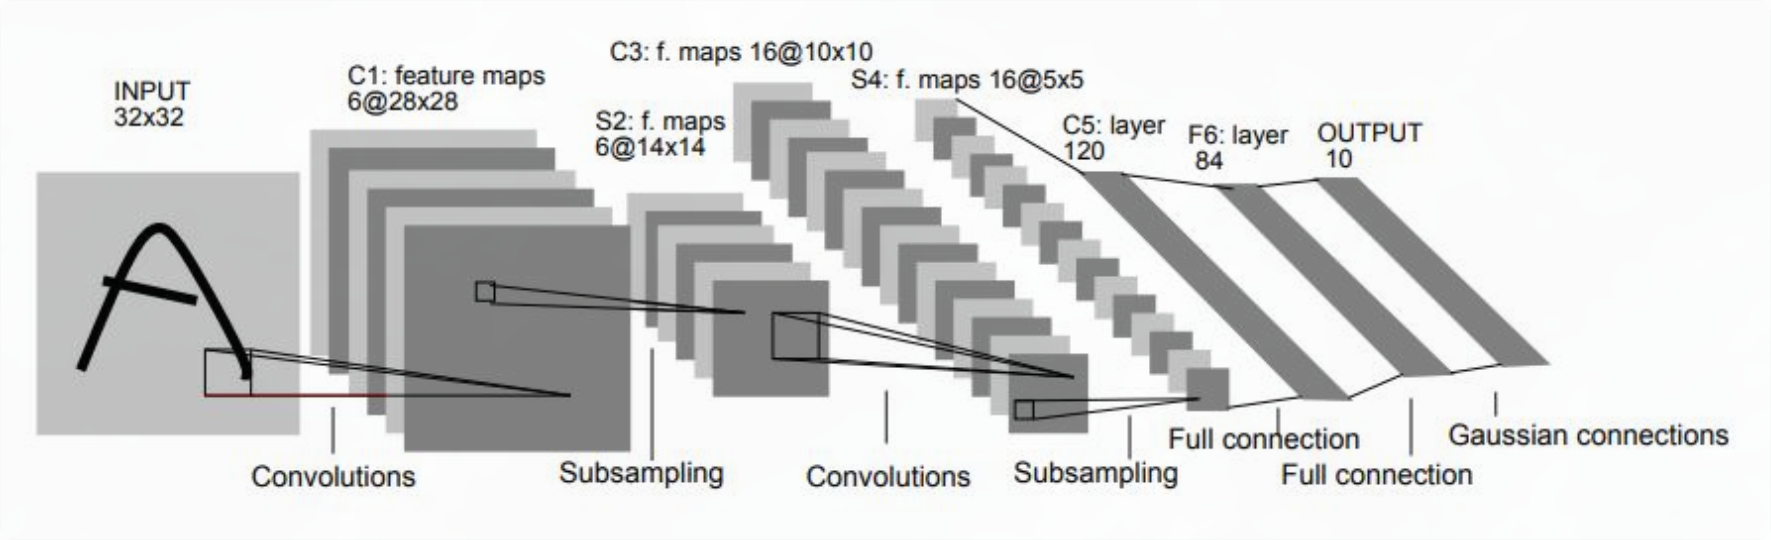

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import wandb

from IPython.display import Image, display
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset

import torchvision
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split

from matplotlib.patches import FancyBboxPatch
from matplotlib.animation import FuncAnimation

plt.style.use("seaborn-v0_8-whitegrid")

In [ ]:
wandb.login()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: varun-edachali (varun-edachali-iiit-hyderabad) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [ ]:
def get_dataloaders(val_ratio=0.1, batch_size=128, seed=42, transform=None):
    if transform is None:
        transform = transforms.ToTensor()

    full_train = datasets.CIFAR10(
        root="data", train=True, transform=transform, download=True
    )
    test_dataset = datasets.CIFAR10(
        root="data", train=False, transform=transform, download=True
    )

    # Split train into train/val
    train_indices, val_indices = train_test_split(
        np.arange(len(full_train)),
        test_size=val_ratio,
        random_state=seed,
        stratify=full_train.targets,
    )

    train_dataset = Subset(full_train, train_indices)
    val_dataset = Subset(full_train, val_indices)

    print(
        f"Dataset sizes: train={len(train_dataset)}, val={len(val_dataset)}, test={len(test_dataset)}"
    )

    train_loader = DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True, num_workers=4
    )
    val_loader = DataLoader(
        val_dataset, batch_size=batch_size, shuffle=False, num_workers=4
    )
    test_loader = DataLoader(
        test_dataset, batch_size=batch_size, shuffle=False, num_workers=4
    )

    return train_loader, val_loader, test_loader

**Q**: why do we shuffle the train set?

In [ ]:
class LeNet5(nn.Module):
    def __init__(self, num_classes=10, pool_type="max", kernel_size=5):
        super().__init__()

        if pool_type == "max":
            self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
            self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        elif pool_type == "avg":
            self.pool1 = nn.AvgPool2d(kernel_size=2, stride=2)
            self.pool2 = nn.AvgPool2d(kernel_size=2, stride=2)
        else:
            raise ValueError(f"pool_type must be 'max' or 'avg', got '{pool_type}'")

        self.conv1 = nn.Conv2d(3, 6, kernel_size=kernel_size)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=kernel_size)

        size = 32  # CIFAR-10 is 32x32
        size = (size - kernel_size) // 1 + 1  # conv1 (stride=1)
        size = (size - 2) // 2 + 1  # pool1 (kernel=2, stride=2)
        size = (size - kernel_size) // 1 + 1  # conv2 (stride=1)
        size = (size - 2) // 2 + 1  # pool2 (kernel=2, stride=2)

        self.fc1 = nn.Linear(16 * size * size, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, num_classes)

    def forward(self, x):
        x = self.pool1(torch.tanh(self.conv1(x)))
        x = self.pool2(torch.tanh(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = torch.tanh(self.fc1(x))
        x = torch.tanh(self.fc2(x))
        logits = self.fc3(x)
        return logits

In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


In [ ]:
def compute_accuracy(model, data_loader, device):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100.0 * correct / total

**Q:** Why do we need both `torch.no_grad()` and `model.eval()`?

In [ ]:
def train(
    model,
    train_loader,
    val_loader,
    num_epochs=25,
    lr=0.001,
    checkpoint_path="best_model.pth",
    device=DEVICE,
):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss(reduction="sum") # default = mean

    best_val_acc = 0.0

    print(f"\nTraining for {num_epochs} epochs...")
    print("-" * 60)

    for epoch in range(num_epochs):
        # Training phase
        model.train()
        total_loss = 0.0
        total_samples = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()

            optimizer.step()

            total_loss += loss.item()
            total_samples += labels.size(0)

        avg_loss = total_loss / total_samples
        train_acc = compute_accuracy(model, train_loader, device)
        val_acc = compute_accuracy(model, val_loader, device)

        # Log to wandb
        wandb.log(
            {
                "train_loss": avg_loss,
                "train_acc": train_acc,
                "val_acc": val_acc,
            }
        )

        # Save best checkpoint
        saved = ""
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(
                {
                    "epoch": epoch + 1,
                    "model_state_dict": model.state_dict(),
                    "val_acc": val_acc,
                },
                checkpoint_path,
            )
            saved = " [SAVED]"

        print(
            f"Epoch [{epoch+1:2d}/{num_epochs}] "
            f"Loss: {avg_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%{saved}"
        )

    print("-" * 60)
    print(f"Best validation accuracy: {best_val_acc:.2f}%")

**Q**: Why do we use `reduction="sum"` here?

Note: this is only really required because we choose to divide by the total samples at the end. In practice, it is likely better to use `reduction="mean"` and divide by the total number of batches at the end to calculate the average loss. This ensures that the losses within a single step (that we backpropogate over) do not get too large while still ensuring uniform loss metrics are reported.

Ref : https://docs.pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html

In [ ]:
def load_checkpoint(model, checkpoint_path, device=DEVICE):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    print(
        f"Loaded checkpoint from epoch {checkpoint['epoch']} (val_acc: {checkpoint['val_acc']:.2f}%)"
    )
    return model

def run_experiment(
    model_name,
    train_loader,
    val_loader,
    test_loader,
    pool_type="max",
    kernel_size=5,
    num_epochs=25,
    lr=0.001,
):
    wandb.init(
        project="lenet-cifar10",
        name=model_name,
        config={
            "pool_type": pool_type,
            "kernel_size": kernel_size,
            "num_epochs": num_epochs,
            "lr": lr,
        },
    )

    model = LeNet5(num_classes=10, pool_type=pool_type, kernel_size=kernel_size)
    print(f"\n{'='*60}")
    print(f"Experiment: {model_name}")
    print(f"{'='*60}")

    checkpoint_path = f"{model_name}.pth"
    train(
        model,
        train_loader,
        val_loader,
        num_epochs=num_epochs,
        lr=lr,
        checkpoint_path=checkpoint_path,
    )
    model = load_checkpoint(model, checkpoint_path)
    test_acc = compute_accuracy(model, test_loader, DEVICE)
    print(f"\nTest Accuracy: {test_acc:.2f}%")

    wandb.log({"test_acc": test_acc})
    wandb.finish()

In [ ]:

transform = transforms.Compose(
    [
        transforms.ToTensor(),
    ]
)
train_loader, val_loader, test_loader = get_dataloaders(transform=transform)

lr = 1e-3
num_epochs = 20

Dataset sizes: train=45000, val=5000, test=10000


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


**Q**: Why `ToTensor()`? Why not `torch.from_numpy()` or explicitly convert to a `Tensor` some other way?

In [ ]:
for kernel_size in [3, 5, 7]:
    run_experiment(
        f"lenet_kernel{kernel_size}",
        train_loader,
        val_loader,
        test_loader,
        kernel_size=kernel_size,
        num_epochs=num_epochs,
        lr=lr,
    )


Experiment: lenet_kernel3

Training for 20 epochs...
------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Epoch [ 1/20] Loss: 1.7519 | Train Acc: 45.58% | Val Acc: 45.62% [SAVED]
Epoch [ 2/20] Loss: 1.4549 | Train Acc: 51.25% | Val Acc: 50.32% [SAVED]
Epoch [ 3/20] Loss: 1.3456 | Train Acc: 55.16% | Val Acc: 53.68% [SAVED]
Epoch [ 4/20] Loss: 1.2607 | Train Acc: 58.02% | Val Acc: 56.08% [SAVED]
Epoch [ 5/20] Loss: 1.1975 | Train Acc: 59.59% | Val Acc: 57.84% [SAVED]
Epoch [ 6/20] Loss: 1.1501 | Train Acc: 61.16% | Val Acc: 58.86% [SAVED]
Epoch [ 7/20] Loss: 1.1045 | Train Acc: 62.63% | Val Acc: 59.78% [SAVED]
Epoch [ 8/20] Loss: 1.0671 | Train Acc: 64.59% | Val Acc: 61.20% [SAVED]
Epoch [ 9/20] Loss: 1.0330 | Train Acc: 65.61% | Val Acc: 62.42% [SAVED]
Epoch [10/20] Loss: 1.0014 | Train Acc: 65.98% | Val Acc: 61.82%
Epoch [11/20] Loss: 0.9776 | Train Acc: 67.04% | Val Acc: 62.36%
Epoch [12/20] Loss: 0.9472 | Train Acc: 68.89% | Val Acc: 63.38% [SAVED]
Epoch [13/20] Loss: 0.9154 | Train Acc: 69.40% | Val Acc: 63.62% [SAVED]
Epoch [14/20] Loss: 0.8906 | Train Acc: 69.87% | Val Acc: 64.12% [S

test_acc,▁
train_acc,▁▂▃▄▄▅▅▅▆▆▆▆▆▇▇▇▇███
train_loss,█▆▅▅▄▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁
val_acc,▁▃▄▅▅▆▆▇▇▇▇▇▇███████
test_acc,63.78
train_acc,76.05778
train_loss,0.74017
val_acc,64.72



Experiment: lenet_kernel5

Training for 20 epochs...
------------------------------------------------------------
Epoch [ 1/20] Loss: 1.7498 | Train Acc: 44.96% | Val Acc: 46.02% [SAVED]
Epoch [ 2/20] Loss: 1.4706 | Train Acc: 49.75% | Val Acc: 49.92% [SAVED]
Epoch [ 3/20] Loss: 1.3563 | Train Acc: 53.77% | Val Acc: 52.72% [SAVED]
Epoch [ 4/20] Loss: 1.2744 | Train Acc: 57.22% | Val Acc: 55.70% [SAVED]
Epoch [ 5/20] Loss: 1.2101 | Train Acc: 59.01% | Val Acc: 57.14% [SAVED]
Epoch [ 6/20] Loss: 1.1568 | Train Acc: 60.62% | Val Acc: 58.06% [SAVED]
Epoch [ 7/20] Loss: 1.1119 | Train Acc: 61.43% | Val Acc: 59.34% [SAVED]
Epoch [ 8/20] Loss: 1.0693 | Train Acc: 63.01% | Val Acc: 59.96% [SAVED]
Epoch [ 9/20] Loss: 1.0382 | Train Acc: 65.04% | Val Acc: 61.06% [SAVED]
Epoch [10/20] Loss: 1.0033 | Train Acc: 65.36% | Val Acc: 60.68%
Epoch [11/20] Loss: 0.9742 | Train Acc: 67.84% | Val Acc: 61.90% [SAVED]
Epoch [12/20] Loss: 0.9409 | Train Acc: 69.04% | Val Acc: 62.50% [SAVED]
Epoch [13/20] Los

test_acc,▁
train_acc,▁▂▃▄▄▅▅▅▆▆▆▆▆▇▇▇▇█▇█
train_loss,█▆▅▅▄▄▄▃▃▃▃▂▂▂▂▂▁▁▁▁
val_acc,▁▃▄▅▆▆▆▇▇▇██▇███████
test_acc,62.47
train_acc,76.11111
train_loss,0.73873
val_acc,63.1



Experiment: lenet_kernel7

Training for 20 epochs...
------------------------------------------------------------
Epoch [ 1/20] Loss: 1.8070 | Train Acc: 40.94% | Val Acc: 40.72% [SAVED]
Epoch [ 2/20] Loss: 1.5602 | Train Acc: 46.10% | Val Acc: 45.36% [SAVED]
Epoch [ 3/20] Loss: 1.4655 | Train Acc: 48.93% | Val Acc: 47.26% [SAVED]
Epoch [ 4/20] Loss: 1.3981 | Train Acc: 51.86% | Val Acc: 51.18% [SAVED]
Epoch [ 5/20] Loss: 1.3538 | Train Acc: 53.52% | Val Acc: 51.48% [SAVED]
Epoch [ 6/20] Loss: 1.3099 | Train Acc: 54.18% | Val Acc: 52.50% [SAVED]
Epoch [ 7/20] Loss: 1.2741 | Train Acc: 53.86% | Val Acc: 52.00%
Epoch [ 8/20] Loss: 1.2447 | Train Acc: 56.40% | Val Acc: 54.54% [SAVED]
Epoch [ 9/20] Loss: 1.2197 | Train Acc: 57.61% | Val Acc: 54.70% [SAVED]
Epoch [10/20] Loss: 1.1934 | Train Acc: 57.70% | Val Acc: 55.00% [SAVED]
Epoch [11/20] Loss: 1.1680 | Train Acc: 59.95% | Val Acc: 57.28% [SAVED]
Epoch [12/20] Loss: 1.1520 | Train Acc: 60.73% | Val Acc: 57.44% [SAVED]
Epoch [13/20] Los

test_acc,▁
train_acc,▁▂▃▄▅▅▅▅▆▆▆▇▇▇▇▇████
train_loss,█▆▅▄▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁
val_acc,▁▃▃▅▅▅▅▆▆▆▇▇▇▇▇▇████
test_acc,57.61
train_acc,65.19778
train_loss,1.01643
val_acc,58.36


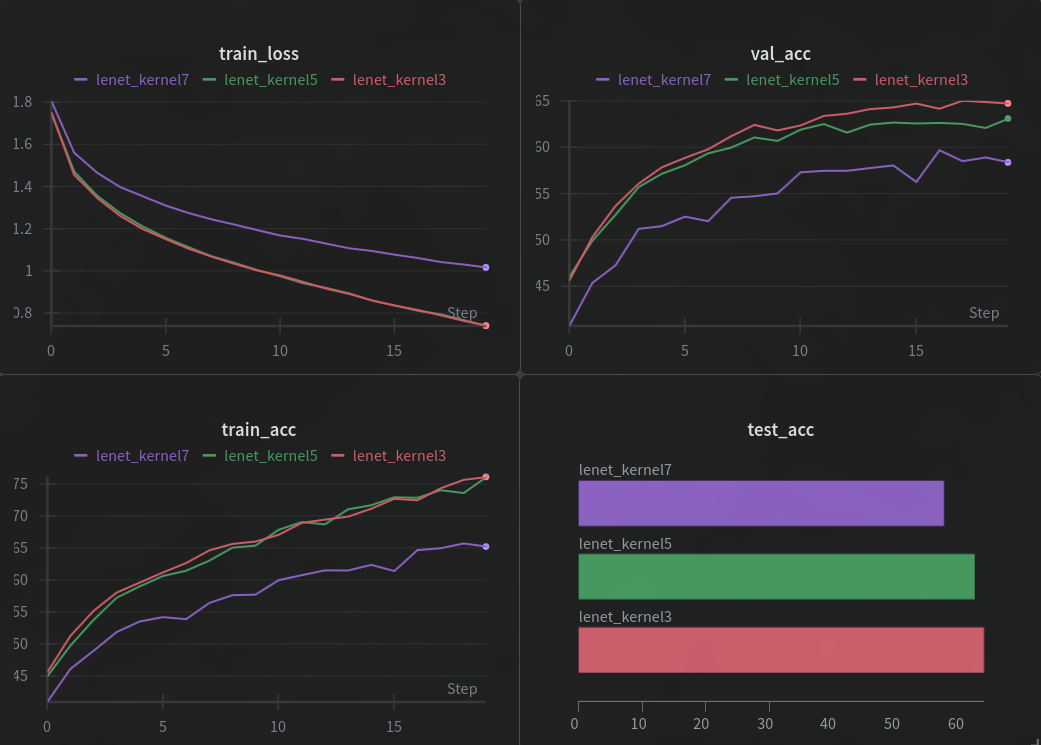

**Q**: Why may the kernel size of 3 be yielding the best performance?

In [ ]:
for pool_type in ["max", "avg"]:
    run_experiment(
        f"lenet_{pool_type}pool",
        train_loader,
        val_loader,
        test_loader,
        pool_type=pool_type,
        num_epochs=num_epochs,
        lr=lr,
    )


Experiment: lenet_maxpool

Training for 20 epochs...
------------------------------------------------------------
Epoch [ 1/20] Loss: 1.7654 | Train Acc: 43.68% | Val Acc: 44.06% [SAVED]
Epoch [ 2/20] Loss: 1.4934 | Train Acc: 49.29% | Val Acc: 48.22% [SAVED]
Epoch [ 3/20] Loss: 1.3750 | Train Acc: 52.40% | Val Acc: 51.64% [SAVED]
Epoch [ 4/20] Loss: 1.2967 | Train Acc: 55.75% | Val Acc: 54.22% [SAVED]
Epoch [ 5/20] Loss: 1.2301 | Train Acc: 57.26% | Val Acc: 55.72% [SAVED]
Epoch [ 6/20] Loss: 1.1779 | Train Acc: 60.52% | Val Acc: 58.28% [SAVED]
Epoch [ 7/20] Loss: 1.1341 | Train Acc: 61.36% | Val Acc: 58.68% [SAVED]
Epoch [ 8/20] Loss: 1.0925 | Train Acc: 62.05% | Val Acc: 59.78% [SAVED]
Epoch [ 9/20] Loss: 1.0567 | Train Acc: 64.57% | Val Acc: 60.64% [SAVED]
Epoch [10/20] Loss: 1.0257 | Train Acc: 65.58% | Val Acc: 61.58% [SAVED]
Epoch [11/20] Loss: 0.9933 | Train Acc: 65.11% | Val Acc: 60.12%
Epoch [12/20] Loss: 0.9627 | Train Acc: 68.77% | Val Acc: 62.20% [SAVED]
Epoch [13/20] Los

test_acc,▁
train_acc,▁▂▃▄▄▅▅▅▆▆▆▇▇▇▇▇▇▇██
train_loss,█▆▅▅▄▄▄▃▃▃▃▂▂▂▂▂▁▁▁▁
val_acc,▁▃▄▅▅▆▆▇▇▇▇███▇█████
test_acc,62.82
train_acc,75.30444
train_loss,0.76164
val_acc,62.94



Experiment: lenet_avgpool

Training for 20 epochs...
------------------------------------------------------------
Epoch [ 1/20] Loss: 1.8965 | Train Acc: 36.36% | Val Acc: 35.82% [SAVED]
Epoch [ 2/20] Loss: 1.7013 | Train Acc: 41.69% | Val Acc: 41.14% [SAVED]
Epoch [ 3/20] Loss: 1.5835 | Train Acc: 45.49% | Val Acc: 44.64% [SAVED]
Epoch [ 4/20] Loss: 1.4944 | Train Acc: 47.90% | Val Acc: 46.52% [SAVED]
Epoch [ 5/20] Loss: 1.4322 | Train Acc: 50.14% | Val Acc: 48.92% [SAVED]
Epoch [ 6/20] Loss: 1.3853 | Train Acc: 51.73% | Val Acc: 50.02% [SAVED]
Epoch [ 7/20] Loss: 1.3454 | Train Acc: 53.12% | Val Acc: 50.56% [SAVED]
Epoch [ 8/20] Loss: 1.3023 | Train Acc: 54.57% | Val Acc: 52.58% [SAVED]
Epoch [ 9/20] Loss: 1.2726 | Train Acc: 56.06% | Val Acc: 53.54% [SAVED]
Epoch [10/20] Loss: 1.2422 | Train Acc: 57.39% | Val Acc: 53.80% [SAVED]
Epoch [11/20] Loss: 1.2123 | Train Acc: 57.87% | Val Acc: 54.00% [SAVED]
Epoch [12/20] Loss: 1.1894 | Train Acc: 58.52% | Val Acc: 53.98%
Epoch [13/20] Los

test_acc,▁
train_acc,▁▂▃▄▄▅▅▅▆▆▆▆▆▇▇▇▇███
train_loss,█▆▆▅▄▄▄▃▃▃▃▂▂▂▂▂▁▁▁▁
val_acc,▁▃▄▅▅▆▆▇▇▇▇▇▇▇██████
test_acc,55.37
train_acc,66.23111
train_loss,1.01696
val_acc,55.78


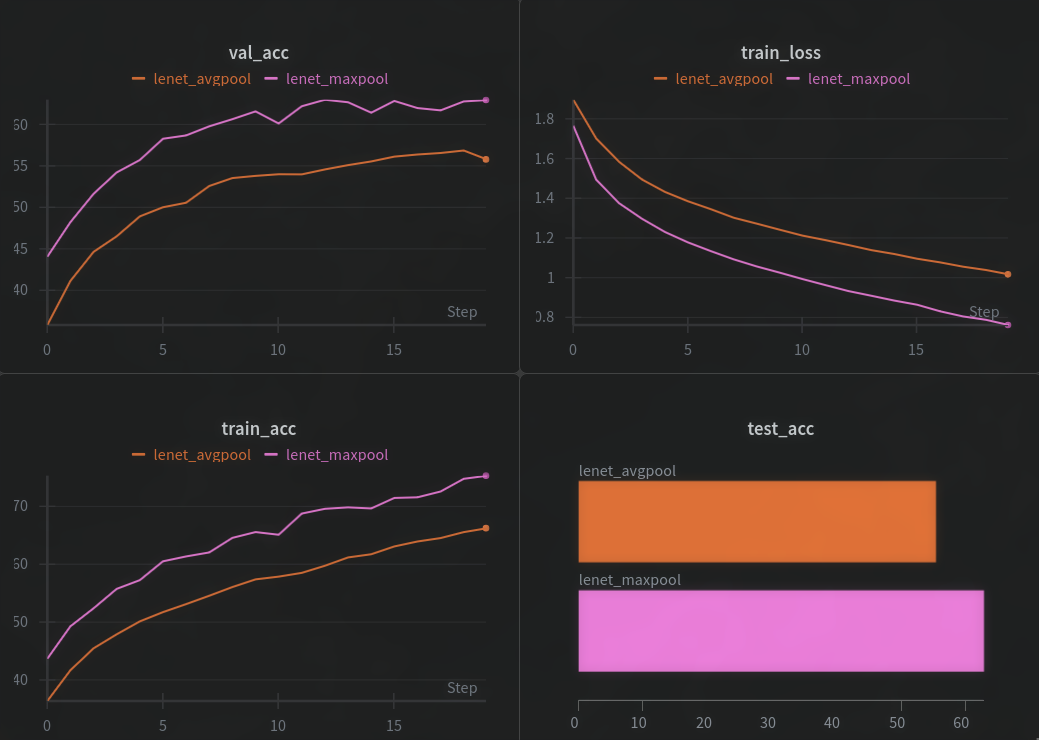

### Comparing Feature Maps

In [ ]:
CLASSES = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
]

In [ ]:
def save_feature_maps(
    checkpoint_path, test_loader, save_dir, num_images=5,
    pool_type="max", kernel_size=5, device=DEVICE
):
    os.makedirs(save_dir, exist_ok=True)

    model = LeNet5(num_classes=10, pool_type=pool_type, kernel_size=kernel_size)
    model = load_checkpoint(model, checkpoint_path, device)
    model = model.to(device)
    model.eval()

    images, labels = next(iter(test_loader))
    images = images[:num_images].to(device)
    labels = labels[:num_images]

    activations = {}
    def get_hook(name):
        def hook(module, input, output):
            activations[name] = output.detach().cpu()
        return hook

    hooks = []
    hooks.append(model.conv1.register_forward_hook(get_hook("conv1")))
    hooks.append(model.pool1.register_forward_hook(get_hook("pool1")))
    hooks.append(model.conv2.register_forward_hook(get_hook("conv2")))
    hooks.append(model.pool2.register_forward_hook(get_hook("pool2")))

    # Forward pass
    with torch.no_grad():
        _ = model(images)

    for h in hooks:
        h.remove()

    for img_idx in range(num_images):
        fig, axes = plt.subplots(4, 17, figsize=(26, 8),
                                 gridspec_kw={'width_ratios': [1]*16 + [0.3]})
        fig.suptitle(f"Image {img_idx} - Label: {CLASSES[labels[img_idx]]}")

        for layer_idx, layer_name in enumerate(["conv1", "pool1", "conv2", "pool2"]):
            feat = activations[layer_name][img_idx]
            num_channels = feat.shape[0]

            for ch in range(16):
                ax = axes[layer_idx, ch]
                if ch < num_channels:
                    im = ax.imshow(feat[ch], cmap="viridis")
                ax.axis("off")

            # Add colorbar for this layer
            cbar_ax = axes[layer_idx, 16]
            cbar = fig.colorbar(im, cax=cbar_ax)
            cbar.set_label(layer_name, rotation=270, labelpad=15)

        plt.tight_layout()
        plt.savefig(os.path.join(save_dir, f"feature_maps_img{img_idx}.png"), dpi=150)
        plt.close()

    print(f"Feature maps saved to {save_dir}/")

save_feature_maps("lenet_maxpool.pth", test_loader, "maxpool", pool_type="max")
save_feature_maps("lenet_avgpool.pth", test_loader, "avgpool", pool_type="avg")

Loaded checkpoint from epoch 13 (val_acc: 62.98%)
Feature maps saved to maxpool/
Loaded checkpoint from epoch 19 (val_acc: 56.86%)
Feature maps saved to avgpool/


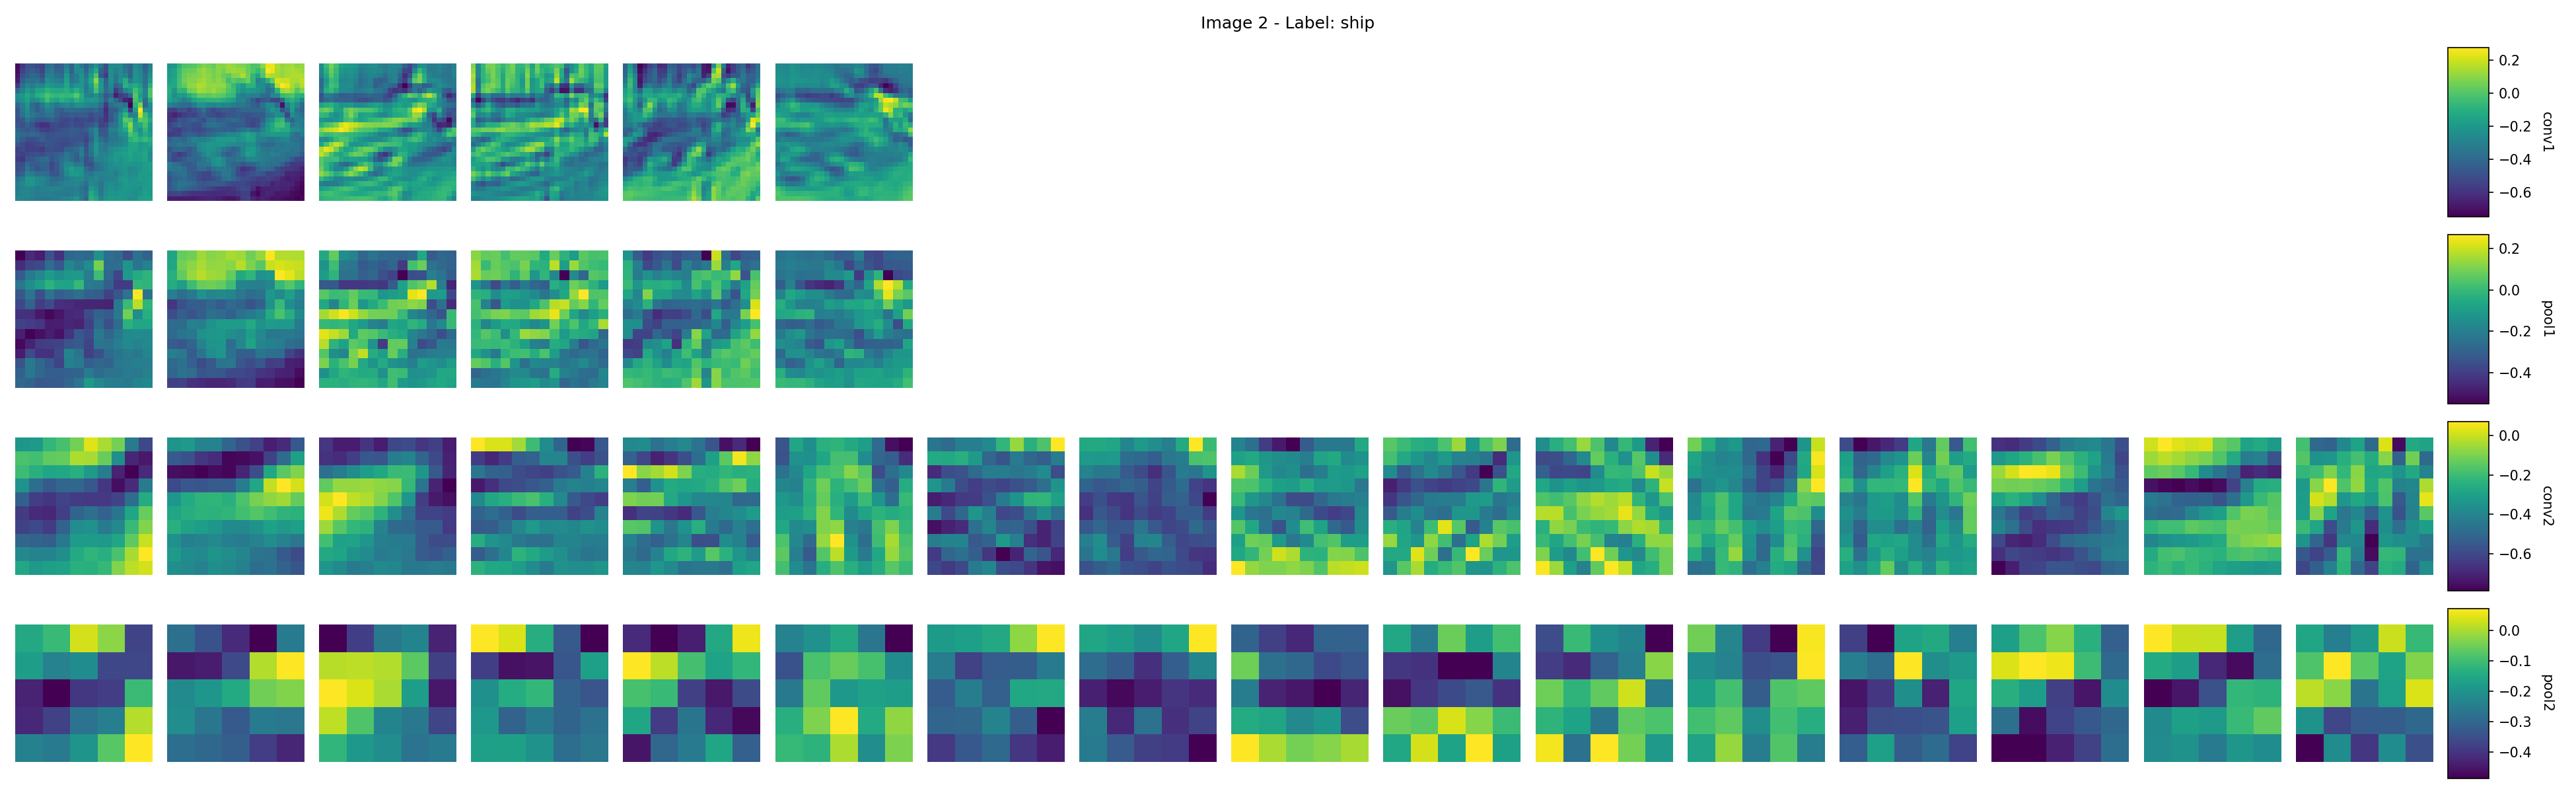

In [ ]:
import cv2
from google.colab.patches import cv2_imshow

img = cv2.imread("maxpool/feature_maps_img2.png")
cv2_imshow(img)

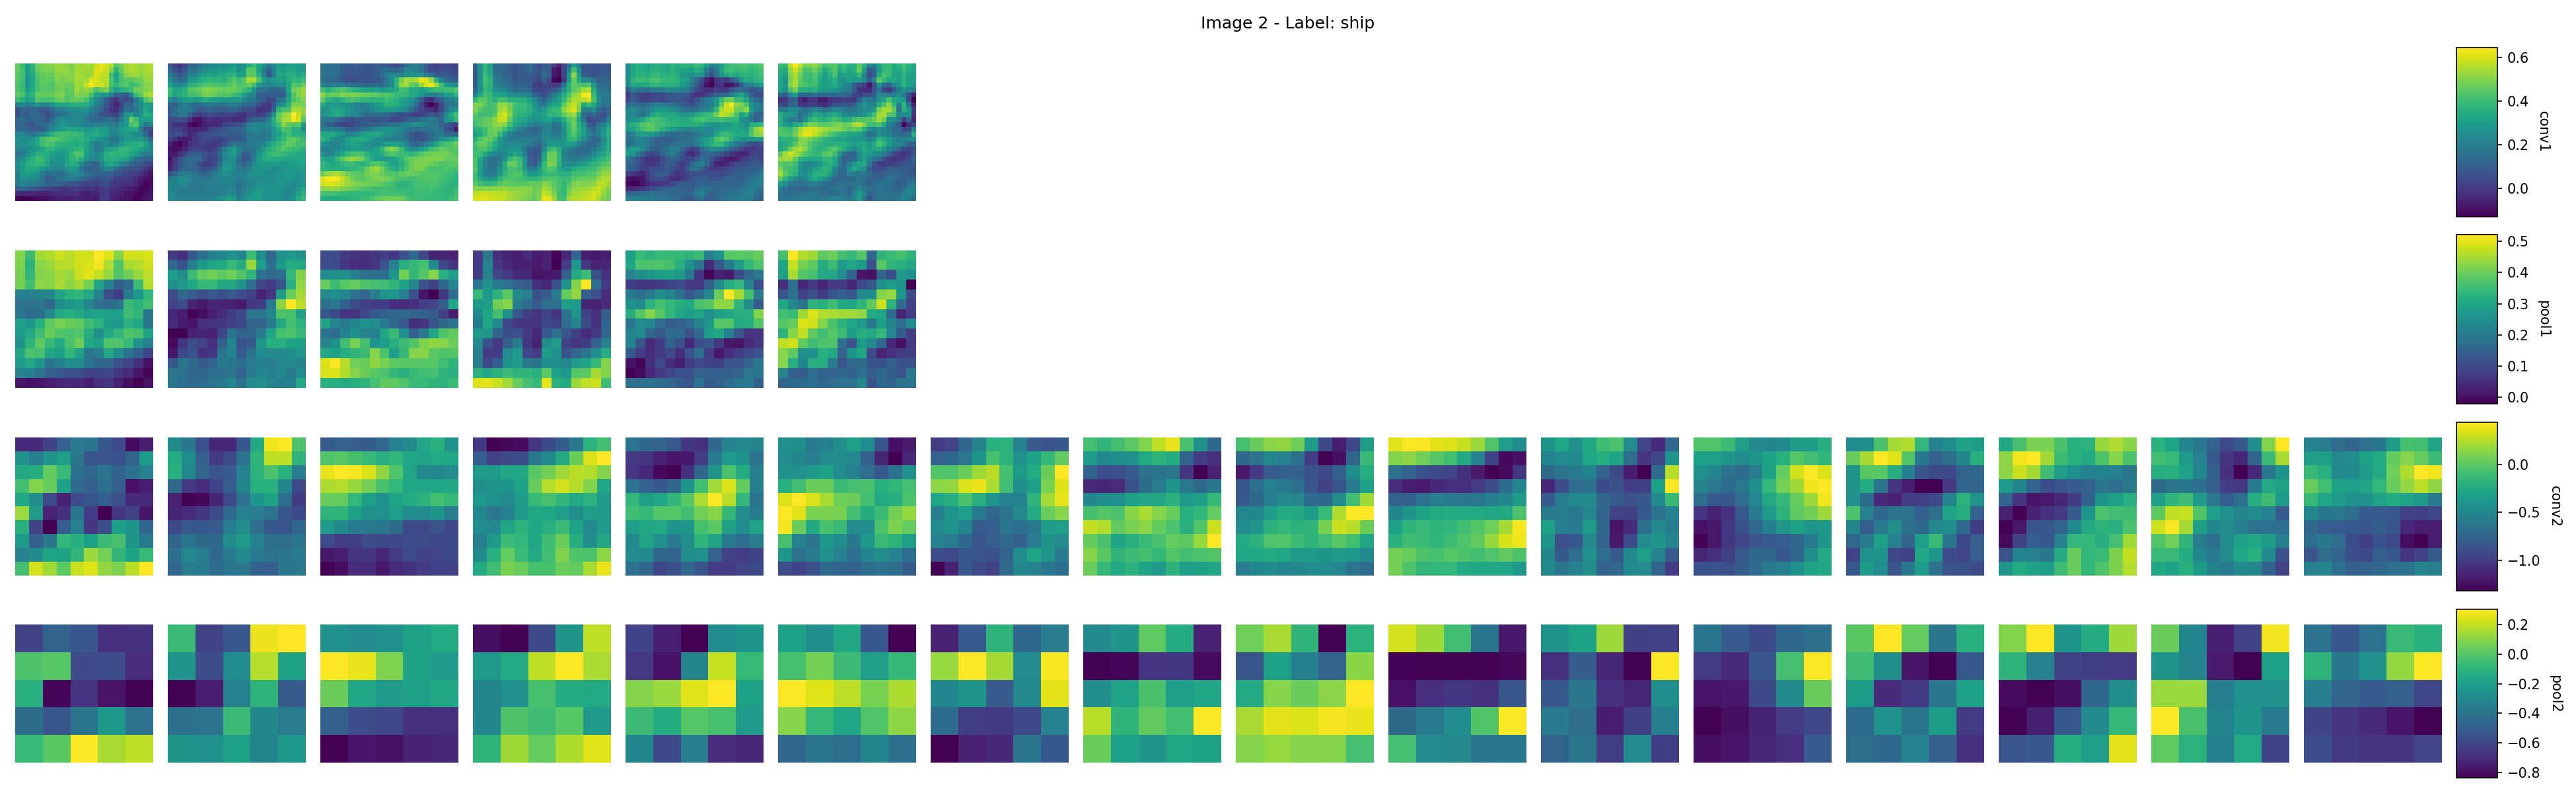

In [ ]:
img = cv2.imread("avgpool/feature_maps_img2.png")
cv2_imshow(img)

**Q**: do you notice a difference between the `max` and `avg` pool features?

**Q**: when may `max` pool be more appropriate than `avg` pool, and vice versa?

## Receptive Field


In [ ]:
def build_rf_table():
    """
    Builds receptive field table layer-by-layer
    """
    layers = []

    rf = 1
    jump = 1
    size = 32
    start = 0.5

    layers.append(("Input", rf, jump, start, size))

    # Conv1 (5x5, stride 1)
    rf += (5 - 1) * jump
    layers.append(("Conv1 (5×5)", rf, jump, start, size - 4))
    size -= 4

    # Pool1 (2x2, stride 2)
    rf += (2 - 1) * jump
    jump *= 2
    size //= 2
    start += jump / 2
    layers.append(("Pool1 (2×2)", rf, jump, start, size))

    # Conv2 (5x5, stride 1)
    rf += (5 - 1) * jump
    layers.append(("Conv2 (5×5)", rf, jump, start, size - 4))
    size -= 4

    # Pool2 (2x2, stride 2)
    rf += (2 - 1) * jump
    jump *= 2
    size //= 2
    start += jump / 2
    layers.append(("Pool2 (2×2)", rf, jump, start, size))

    return layers

Ref for computing receptive field for CNN's : https://distill.pub/2019/computing-receptive-fields/

In [ ]:
def animate_rf(save_path="lenet_rf.gif"):
    transform = transforms.ToTensor()
    dataset = torchvision.datasets.CIFAR10(
        root="./data", train=False, download=True, transform=transform
    )

    image, _ = dataset[np.random.randint(len(dataset))]
    img = image.numpy().transpose(1, 2, 0)

    rf_table = build_rf_table()

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(img)
    ax.set_xlim(-0.5, 31.5)
    ax.set_ylim(31.5, -0.5)
    ax.axis("off")

    title = ax.set_title("", fontsize=14, fontweight="bold")

    rf_box = FancyBboxPatch(
        (0, 0), 1, 1,
        boxstyle="round,pad=0.02",
        linewidth=3,
        edgecolor="yellow",
        facecolor="red",
        alpha=0.25
    )
    ax.add_patch(rf_box)

    center_dot, = ax.plot([], [], "b*", markersize=14)

    def update(i):
        name, rf, jump, start, fmap = rf_table[i]

        y = x = fmap // 2
        cy = start + y * jump
        cx = start + x * jump

        half = rf / 2
        rf_box.set_bounds(cx - half, cy - half, rf, rf)

        center_dot.set_data([cx], [cy])

        rf_pct = min(100, (rf / 32) * 100)

        title.set_text(
            f"{name}\n"
            f"Feature map: {fmap}x{fmap}\n"
            f"Receptive Field: {rf}x{rf} "
            f"({rf_pct:.0f}% of input)"
        )

        return rf_box, center_dot, title

    anim = FuncAnimation(
        fig,
        update,
        frames=len(rf_table),
        interval=1200,
        blit=True
    )

    anim.save(save_path, writer="pillow")
    plt.close(fig)

    print(f" Saved GIF: {save_path}")
    display(Image(filename=save_path))


 Saved GIF: lenet_rf.gif


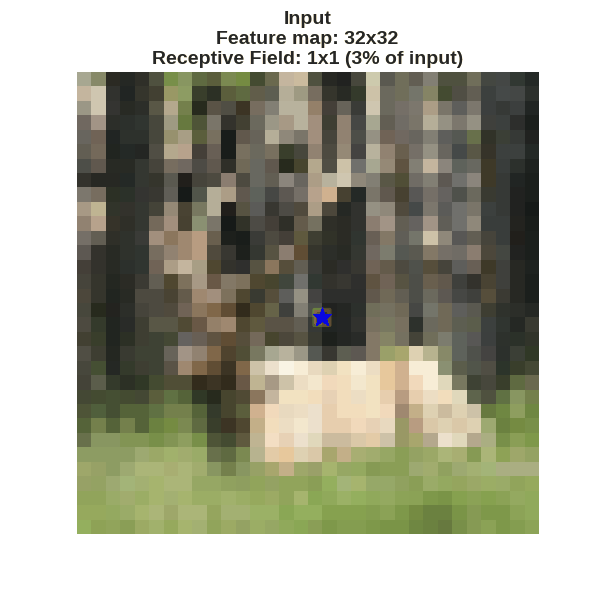

In [ ]:
animate_rf()

**Q** : Does `2x2` max pooling double the receptive field?

## Non - Linear Activation

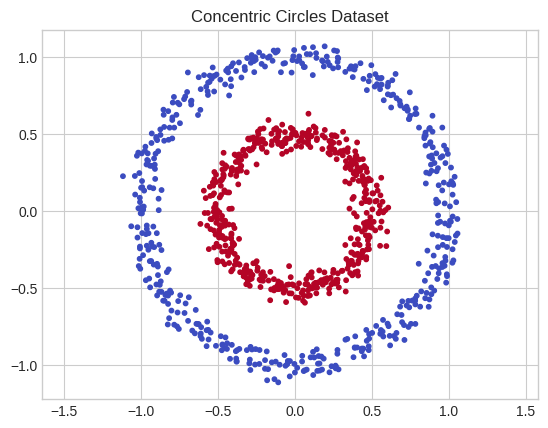

In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

X, y = make_circles(
    n_samples=1000,
    noise=0.05,
    factor=0.5,
    random_state=42
)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", s=10)
plt.axis("equal")
plt.title("Concentric Circles Dataset")
plt.show()

In [ ]:
from sklearn.neural_network import MLPClassifier

# Medium sized models

relu_clf = MLPClassifier(
    hidden_layer_sizes=(16, 16),
    activation="relu",
    solver="adam",
    max_iter=3000,
    random_state=42
)

relu_clf.fit(X, y)

tanh_clf = MLPClassifier(
    hidden_layer_sizes=(16, 16),
    activation="tanh",
    solver="adam",
    max_iter=3000,
    random_state=42
)

tanh_clf.fit(X, y)

MLPClassifier(activation='tanh', hidden_layer_sizes=(16, 16), max_iter=3000,
              random_state=42)

In [ ]:
def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 500),
        np.linspace(y_min, y_max, 500)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", s=10)
    plt.axis("equal")
    plt.title(title)
    plt.show()

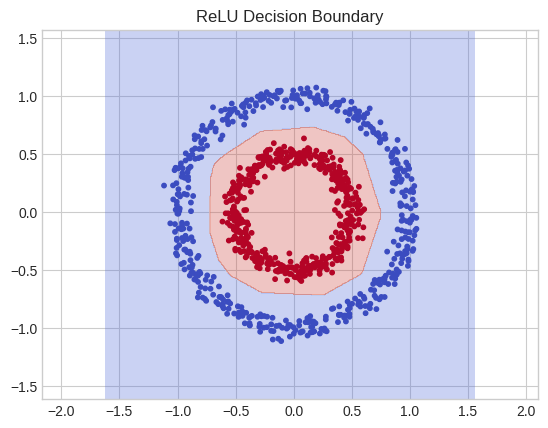

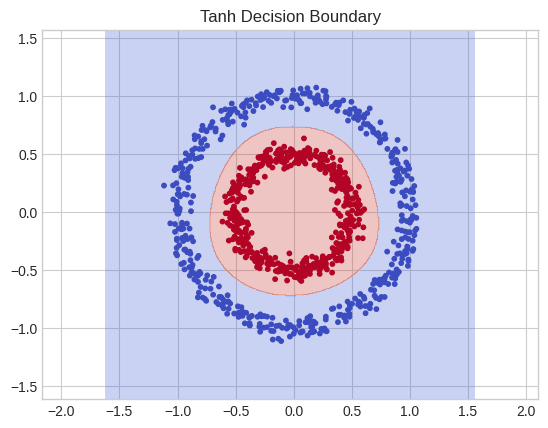

In [ ]:
plot_decision_boundary(relu_clf, X, y, "ReLU Decision Boundary")

plot_decision_boundary(tanh_clf, X, y, "Tanh Decision Boundary")

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [ ]:
# Weaker models !

relu_model = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(6,),
        activation="relu",
        solver="adam",
        max_iter=3000,
        random_state=0
    ))
])

relu_model.fit(X, y)

tanh_model = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(6,),
        activation="tanh",
        solver="adam",
        max_iter=3000,
        random_state=0
    ))
])

tanh_model.fit(X, y)

Pipeline(steps=[('scaler', StandardScaler()),
                ('mlp',
                 MLPClassifier(activation='tanh', hidden_layer_sizes=(6,),
                               max_iter=3000, random_state=0))])

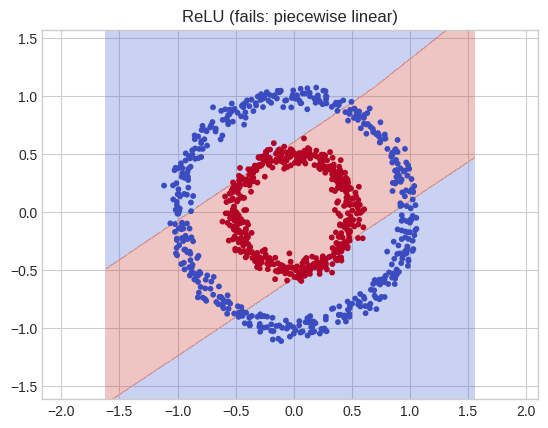

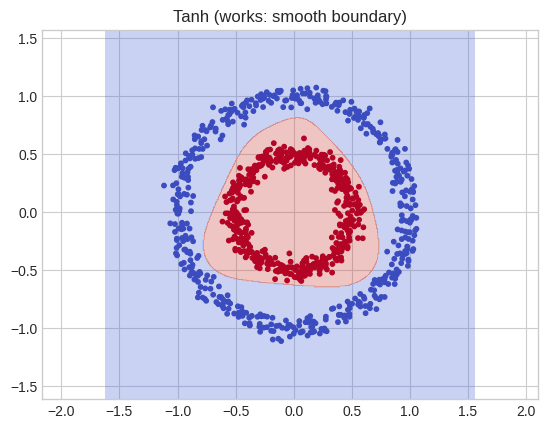

In [ ]:
plot_decision_boundary(relu_model, X, y, "ReLU (fails: piecewise linear)")
plot_decision_boundary(tanh_model, X, y, "Tanh (works: smooth boundary)")

**Q** : Can you think of a case where `relu` would be a more preferrable choice of activation than`tanh`?

## t-SNE visualization

In [ ]:
def extract_features(model, loader, device, max_samples=2000):
    model.eval()
    model.to(device)

    features = []
    labels = []
    num_collected = 0

    with torch.no_grad():
        for images, targets in loader:
            images = images.to(device)

            # forward up to fc2
            x = model.pool1(torch.tanh(model.conv1(images)))
            x = model.pool2(torch.tanh(model.conv2(x)))
            x = x.view(x.size(0), -1)
            x = torch.tanh(model.fc1(x))
            x = torch.tanh(model.fc2(x))

            features.append(x.cpu())
            labels.append(targets.cpu())

            num_collected += x.size(0)
            if num_collected >= max_samples:
                break

    features = torch.cat(features, dim=0)[:max_samples]
    labels = torch.cat(labels, dim=0)[:max_samples]

    return features.numpy(), labels.numpy()


In [ ]:
from sklearn.manifold import TSNE
import seaborn as sns


def plot_tsne(features, labels, class_names, title="t-SNE of LeNet Features"):
    tsne = TSNE(
        n_components=2,
        perplexity=30,
        learning_rate=200,
        n_iter=1000,
        random_state=42,
    )

    z = tsne.fit_transform(features)

    plt.figure(figsize=(8, 8))
    ax = sns.scatterplot(
        x=z[:, 0],
        y=z[:, 1],
        hue=labels,
        palette="tab10",
        s=20,
        linewidth=0,
        alpha=0.8,
        legend="full",
    )

    handles, _ = ax.get_legend_handles_labels()
    ax.legend(
        handles,
        class_names,
        title="Class",
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
    )

    plt.title(title, fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()



In [ ]:
kernel_size = 3
lr = 1e-3
num_epochs = 20

run_experiment(
    model_name=f"lenet_kernel{kernel_size}",
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    kernel_size=kernel_size,
    num_epochs=num_epochs,
    lr=lr,
)


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

In [ ]:
model = LeNet5(kernel_size=kernel_size)
model = load_checkpoint(model, f"lenet_kernel{kernel_size}.pth", DEVICE)

features, labels = extract_features(
    model, test_loader, DEVICE, max_samples=2000
)


Loaded checkpoint from epoch 17 (val_acc: 65.06%)


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


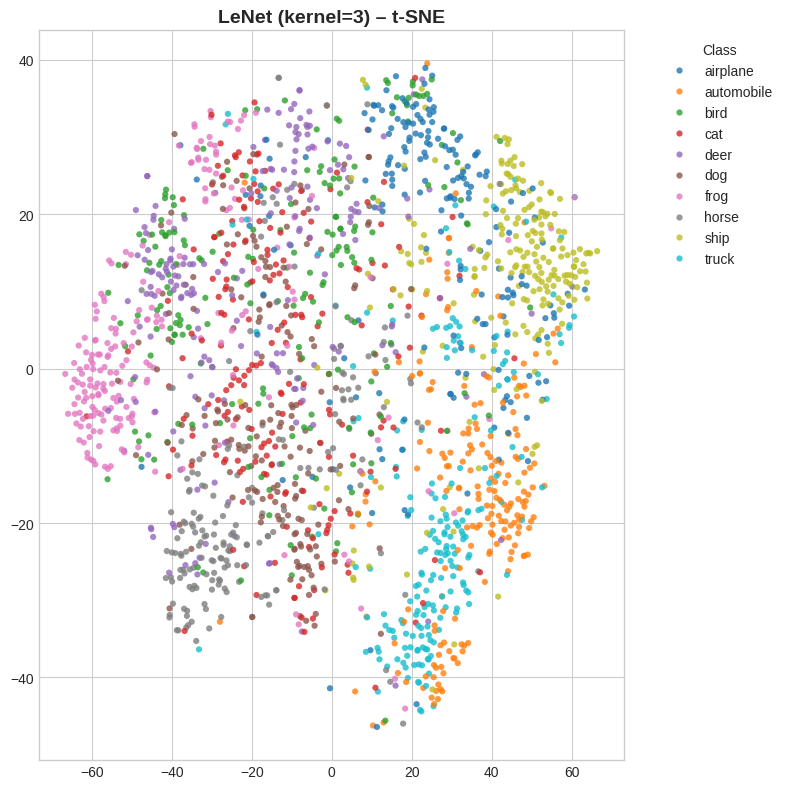

In [ ]:
plot_tsne(
    features,
    labels,
    CLASSES ,
    title=f"LeNet (kernel={kernel_size}) – t-SNE"
)

Ref : https://medium.com/@sachinsoni600517/mastering-t-sne-t-distributed-stochastic-neighbor-embedding-0e365ee898ea

**Q**: What's the difference between t-SNE and PCA(2D)?

**Q** : What's the effect of perplexity (sigma) parameter on t-SNE clustering ?

## Batch Normalization

![machine learning - Why do transformers use layer norm instead of batch norm?  - Cross Validated](https://i.sstatic.net/E3104.png)

**Convention for Input to a conv layer**

$X \in \mathbb{R}^{B \times C \times H \times W}$
### Normalization

$\mu_c = \frac{1}{BHW}\sum_{b,h,w} X_{b,c,h,w}$
$\sigma_c^2 = \frac{1}{BHW}\sum_{b,h,w}(X_{b,c,h,w}-\mu_c)^2$

$\hat{X}_{b,c,h,w} = \frac{X_{b,c,h,w}-\mu_c}{\sqrt{\sigma_c^2+\epsilon}}$
### Scale and Transform

$Y_{b,c,h,w} = \gamma_c,\hat{X}_{b,c,h,w} + \beta_c$

Spatially varying parameters would imply:  
$\gamma_{c,h,w},\beta_{c,h,w} \quad\Rightarrow\quad  \mu_{c,h,w},\sigma_{c,h,w}$

which breaks translation equivariance and is no longer BatchNorm.
Translational equivariance:  $f(T_\Delta x) = T_\Delta f(x)$ i.e., shifting the input by ($\Delta$) shifts the output by the same.

**During inference:**  
$\mu_c,\sigma_c^2 ;\text{are fixed (running statistics), not batch-computed}$
so BatchNorm becomes **deterministic and independent of the test batch**.

